<a href="https://colab.research.google.com/github/Aaeeron/Bearing_live_expectancy/blob/main/IMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The dataset contains three separate data sets describing test-to-failure experiments. Instead of a single clean spreadsheet, the data is separated into hundreds of individual text files.

Set No. 2:

The Timeline: The motor ran continuously for several days.

The Files: There are 984 individual files. The file name indicates when the data was collected, with recordings taken at 10-minute intervals.

The Data: Each file is a 1-second vibration signal snapshot containing 20,480 points with the sampling rate set at 20 kHz.

The Outcome: At the end of the test-to-failure experiment, an outer race failure occurred in bearing 1.



Streaming output truncated to the last 5000 lines.
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.15.22.46            18%  OK 
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.15.32.46            18%  OK 
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.15.42.46            18%  OK 
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.15.52.46            18%  OK 
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.16.02.46            18%  OK 
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.16.12.46            18%  OK 
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.16.22.46            18%  OK 
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.16.32.46            18%  OK 
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.16.42.46            18%  OK 
Extracting  /content/3rd_test/4th_test/txt/2004.03.13.16.52.46            18%  OK 
Extracting  /content/3rd_test

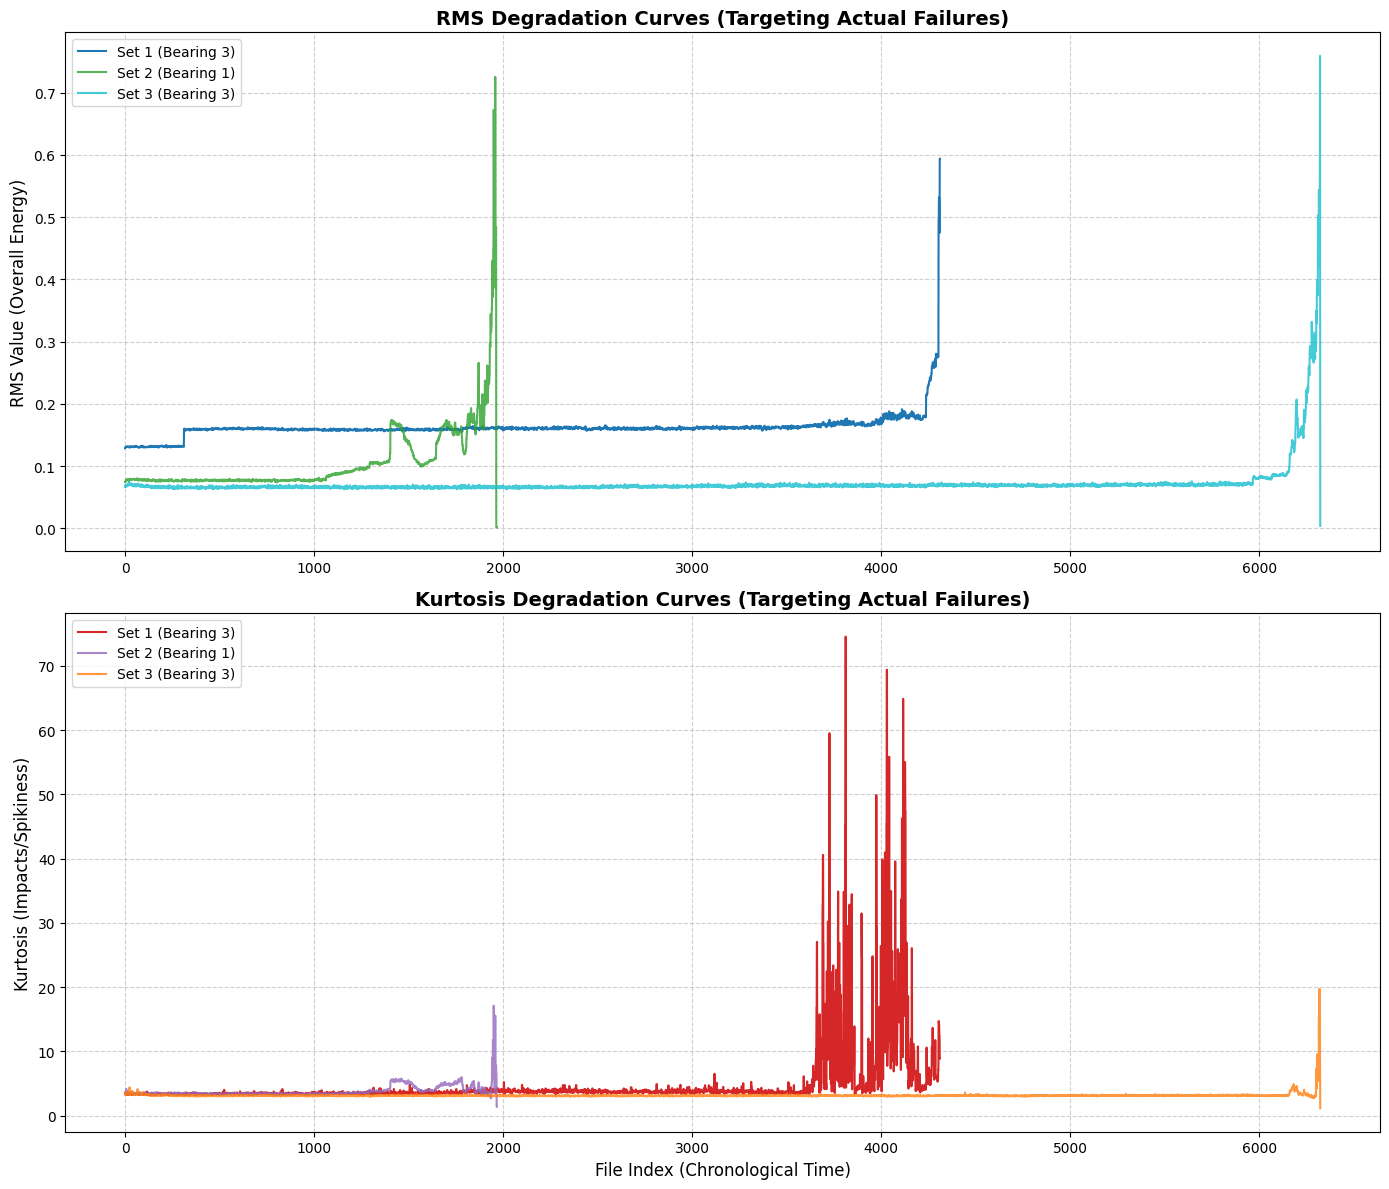

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# --- 1. Extract the .rar files directly into their respective folders ---
# STRICTLY using the 3 datasets from the documentation
datasets = ['1st_test', '2nd_test', '3rd_test']

print("Starting extraction process...")
for name in datasets:
    rar_path = f"/content/{name}.rar"
    target_folder = f"/content/{name}"

    if os.path.exists(rar_path):
        print(f"Extracting {rar_path} into {target_folder}/ ...")
        os.makedirs(target_folder, exist_ok=True)
        !unrar x -o+ {rar_path} {target_folder}/
    else:
        print(f"Warning: {rar_path} not found in /content/.")
print("Extraction complete!\n")

# --- 2. Define Feature Extraction Logic ---
def extract_failing_bearing(folder_path, channel_index):
    """
    Reads files in a folder chronologically and extracts RMS and Kurtosis
    for a specific channel index corresponding to the failing bearing.
    """
    if not os.path.exists(folder_path):
        print(f"Warning: Folder '{folder_path}' not found.")
        return [], []

    valid_filepaths = []
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if not filename.endswith(('.txt', '.rar', '.DS_Store')):
                valid_filepaths.append(os.path.join(root, filename))

    valid_filepaths.sort(key=lambda x: os.path.basename(x))

    rms_values = []
    kurtosis_values = []

    for filepath in valid_filepaths:
        try:
            df = pd.read_csv(filepath, sep='\t', header=None)
        except Exception:
            df = pd.read_csv(filepath, delim_whitespace=True, header=None)

        if df.shape[1] > channel_index:
            # Extract the specific channel where the failure occurred
            signal = df.iloc[:, channel_index].values
            rms_values.append(np.sqrt(np.mean(signal**2)))
            kurtosis_values.append(kurtosis(signal, fisher=False))

    return rms_values, kurtosis_values

# --- 3. Process the Data (Targeting the Correct Failing Channels) ---
print("Extracting Set 1 (1st_test) -> Bearing 3 (Channel 5 / Index 4)...")
rms_1, kurt_1 = extract_failing_bearing('/content/1st_test', channel_index=4)

print("Extracting Set 2 (2nd_test) -> Bearing 1 (Channel 1 / Index 0)...")
rms_2, kurt_2 = extract_failing_bearing('/content/2nd_test', channel_index=0)

print("Extracting Set 3 (3rd_test) -> Bearing 3 (Channel 3 / Index 2)...")
rms_3, kurt_3 = extract_failing_bearing('/content/3rd_test', channel_index=2)

# --- 4. Generate Comparison Plots ---
print("\nGenerating plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

# Top Plot: RMS Comparison
if rms_1: ax1.plot(rms_1, label='Set 1 (Bearing 3)', color='tab:blue', linewidth=1.5)
if rms_2: ax1.plot(rms_2, label='Set 2 (Bearing 1)', color='tab:green', linewidth=1.5, alpha=0.8)
if rms_3: ax1.plot(rms_3, label='Set 3 (Bearing 3)', color='tab:cyan', linewidth=1.5, alpha=0.8)

ax1.set_title('RMS Degradation Curves (Targeting Actual Failures)', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMS Value (Overall Energy)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Kurtosis Comparison
if kurt_1: ax2.plot(kurt_1, label='Set 1 (Bearing 3)', color='tab:red', linewidth=1.5)
if kurt_2: ax2.plot(kurt_2, label='Set 2 (Bearing 1)', color='tab:purple', linewidth=1.5, alpha=0.8)
if kurt_3: ax2.plot(kurt_3, label='Set 3 (Bearing 3)', color='tab:orange', linewidth=1.5, alpha=0.8)

ax2.set_title('Kurtosis Degradation Curves (Targeting Actual Failures)', fontsize=14, fontweight='bold')
ax2.set_xlabel('File Index (Chronological Time)', fontsize=12)
ax2.set_ylabel('Kurtosis (Impacts/Spikiness)', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()


Normalizing data to healthy baselines...
Generating normalized plots...


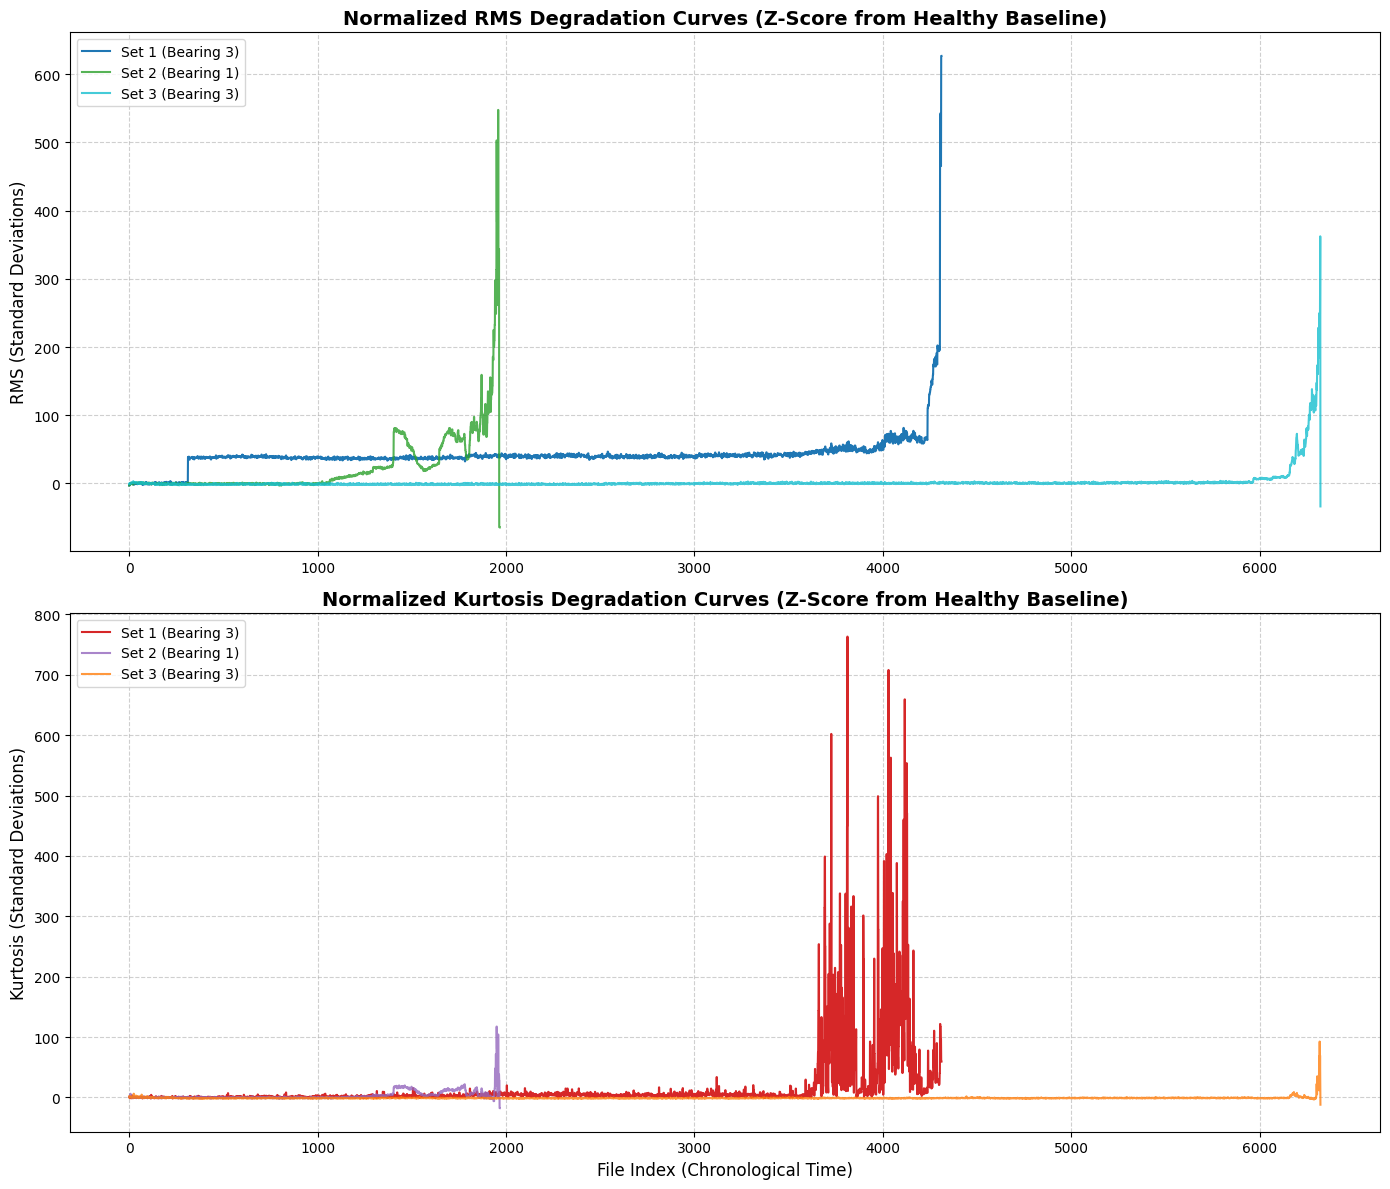

In [ ]:
# --- 4. Apply Healthy Baseline Normalization ---
def normalize_to_baseline(feature_array, baseline_window=200):
    """
    Normalizes an array based on the mean and standard deviation
    of its initial 'healthy' state (first N files).
    """
    if len(feature_array) == 0:
        return []

    feature_array = np.array(feature_array)
    healthy_baseline = feature_array[:baseline_window]

    mu = np.mean(healthy_baseline)
    sigma = np.std(healthy_baseline)

    # Prevent division by zero
    if sigma == 0:
        sigma = 1e-8

    normalized_array = (feature_array - mu) / sigma
    return normalized_array

print("\nNormalizing data to healthy baselines...")
rms_1_norm = normalize_to_baseline(rms_1)
rms_2_norm = normalize_to_baseline(rms_2)
rms_3_norm = normalize_to_baseline(rms_3)

kurt_1_norm = normalize_to_baseline(kurt_1)
kurt_2_norm = normalize_to_baseline(kurt_2)
kurt_3_norm = normalize_to_baseline(kurt_3)

# --- 5. Generate Normalized Comparison Plots ---
print("Generating normalized plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

# Top Plot: Normalized RMS Comparison
if len(rms_1_norm) > 0: ax1.plot(rms_1_norm, label='Set 1 (Bearing 3)', color='tab:blue', linewidth=1.5)
if len(rms_2_norm) > 0: ax1.plot(rms_2_norm, label='Set 2 (Bearing 1)', color='tab:green', linewidth=1.5, alpha=0.8)
if len(rms_3_norm) > 0: ax1.plot(rms_3_norm, label='Set 3 (Bearing 3)', color='tab:cyan', linewidth=1.5, alpha=0.8)

ax1.set_title('Normalized RMS Degradation Curves (Z-Score from Healthy Baseline)', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMS (Standard Deviations)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Normalized Kurtosis Comparison
if len(kurt_1_norm) > 0: ax2.plot(kurt_1_norm, label='Set 1 (Bearing 3)', color='tab:red', linewidth=1.5)
if len(kurt_2_norm) > 0: ax2.plot(kurt_2_norm, label='Set 2 (Bearing 1)', color='tab:purple', linewidth=1.5, alpha=0.8)
if len(kurt_3_norm) > 0: ax2.plot(kurt_3_norm, label='Set 3 (Bearing 3)', color='tab:orange', linewidth=1.5, alpha=0.8)

ax2.set_title('Normalized Kurtosis Degradation Curves (Z-Score from Healthy Baseline)', fontsize=14, fontweight='bold')
ax2.set_xlabel('File Index (Chronological Time)', fontsize=12)
ax2.set_ylabel('Kurtosis (Standard Deviations)', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

Folder (Dataset),Total Files (Time Snapshots),Channels per File,Which Bearing Reached EOL?,Type of Failure (EOL)
Set 1 (1st_test),"2,156 files",8 (2 sensors per bearing),Bearing 3 & Bearing 4,Inner race (B3) & Roller element (B4)
Set 2 (2nd_test),984 files,4 (1 sensor per bearing),Bearing 1,Outer race
Set 3 (3rd_test),"4,448 files",4 (1 sensor per bearing),Bearing 3,Outer race

Calculating Frequency Spectrums (FFT)...


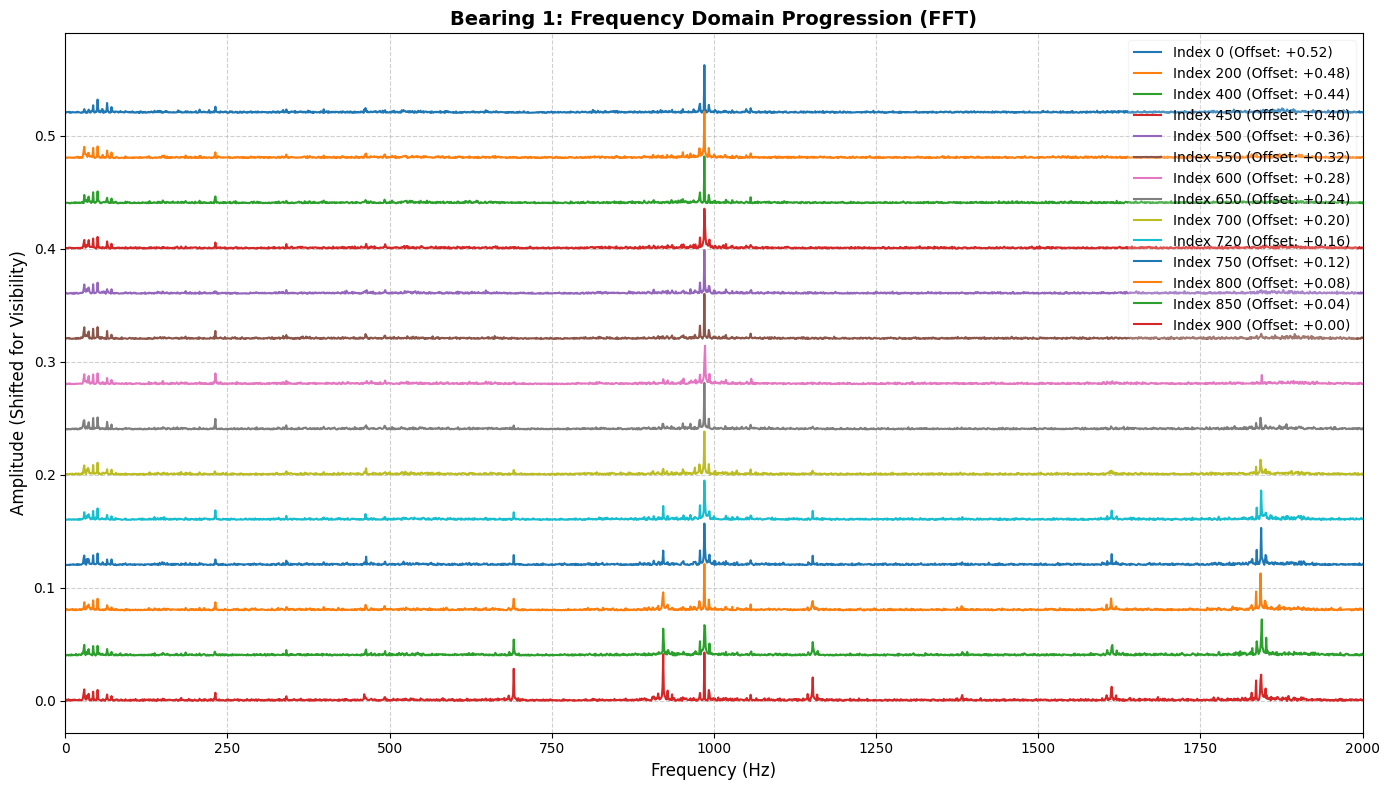

In [ ]:
from scipy.fft import fft, fftfreq

def plot_frequency_domain(folder_path, file_indices):
    print("Calculating Frequency Spectrums (FFT)...")
    file_names = sorted(os.listdir(folder_path))

    # IMS Dataset Parametersg
    fs = 20000      # Sampling rate: 20 kHz
    n_points = 20480  # Points per file

    fig, ax = plt.subplots(figsize=(14, 8))

    # We will plot the selected files
    for idx, file_idx in enumerate(file_indices):
        filename = file_names[file_idx]
        filepath = os.path.join(folder_path, filename)

        try:
            df = pd.read_csv(filepath, sep='\t', header=None)
        except Exception:
            df = pd.read_csv(filepath, delim_whitespace=True, header=None)

        signal = df.iloc[:, 0].values # Isolate Bearing 1

        # --- 1. Compute the FFT ---
        fft_values = fft(signal)
        frequencies = fftfreq(n_points, 1/fs)

        # --- 2. Filter for Positive Frequencies ---
        # The FFT mirrors itself, so we only need the positive half
        pos_mask = frequencies > 0
        freqs_pos = frequencies[pos_mask]

        # Normalize the magnitude
        magnitude = np.abs(fft_values[pos_mask]) * 2.0 / n_points

        # --- 3. Plot with an Offset ---
        # We add a vertical offset to separate the lines so they don't overlap completely
        offset = (len(file_indices) - idx - 1) * 0.04
        ax.plot(freqs_pos, magnitude + offset, label=f'Index {file_idx} (Offset: +{offset:.2f})', linewidth=1.5)

    plt.title('Bearing 1: Frequency Domain Progression (FFT)', fontsize=14, fontweight='bold')
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Amplitude (Shifted for Visibility)', fontsize=12)

    # Bearing fault frequencies usually appear in the lower range.
    # We limit the X-axis to 2000 Hz to zoom in on the important spikes.
    plt.xlim(0, 2000)

    plt.legend(loc='upper right', framealpha = 0.2)

    plt.grid(True, linestyle='--', alpha=0.6)
    fig.tight_layout()
    plt.show()

# --- Execution ---
folder_path = '/content/2nd_test'

# We will compare these specific files:
# 0: Healthy operation
# 400: The microscopic start of the fault
# 530: When RMS finally starts drifting upward
# 750: Catastrophic imminent failure
milestone_files = [0, 200, 400, 450, 500, 550, 600, 650, 700, 720, 750, 800, 850, 900]

plot_frequency_domain(folder_path, milestone_files)

The plot shows that over time the recorded frequencies for every timestamp change. With the dominant background noise at arround 980 Hz and a constant spot at around 60 Hz it becomes obvious that some frequencies only appear over time which is a significant sign for degradation of the bearing. This proves that a neural network can support decision making for when the machine need to be repaired.
### Step 3: Dataset Generation and Train/Valid/Test Splitting

To train the Convolutional Neural Network (CNN) robustly, we will transform our 1D time-series data into 2D spectrograms and simultaneously distribute them into training, validation, and testing directories.

**1. Class Definitions**
Using our established degradation timeline, the dataset is divided into three physical states:
*   **Class 0 (Healthy):** Indices 0 to 530
*   **Class 1 (Degrading):** Indices 531 to 750
*   **Class 2 (Failing):** Indices 751 to 984

**2. The Data Split Strategy**
We will apply a stratified split to ensure every subset maintains the exact same proportion of Healthy, Degrading, and Failing samples:
*   **Train Set ($70\%$):** Used to update the network weights and learn features.
*   **Validation Set ($15\%$):** Used to tune hyperparameters and monitor for overfitting during training.
*   **Test Set ($15\%$):** Held out completely for the final, unbiased evaluation.

**3. Spectrogram Conversion (STFT)**
For each file, we compute the Short-Time Fourier Transform (STFT) and scale it to Decibels (dB) to ensure the fault signatures are highly visible:
$$S_{xx}(\tau, \omega) = 10 \log_{10} \left( |\text{STFT}(\tau, \omega)|^2 + 1\times 10^{-10} \right)$$

To isolate the mechanical vibrations, we will restrict the output to frequencies $\omega \leq 2000 \text{ Hz}$.

In [ ]:
!unrar x "/content/2nd_test.rar" "/content/2nd_test/"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/2nd_test.rar

Creating    /content/2nd_test/2nd_test                                OK
Extracting  /content/2nd_test/2nd_test/2004.02.12.10.32.39                 0%  OK 
Extracting  /content/2nd_test/2nd_test/2004.02.12.10.42.39                 0%  OK 
Extracting  /content/2nd_test/2nd_test/2004.02.12.10.52.39                 0%  OK 
Extracting  /content/2nd_test/2nd_test/2004.02.12.11.02.39                 0%  OK 
Extracting  /content/2nd_test/2nd_test/2004.02.12.11.12.39                 0%  OK 
Extracting  /content/2nd_test/2nd_test/2004.02.12.11.22.39                 0%  OK 
Extracting  /content/2nd_test/2nd_test/2004.02.12.11.32.39                 0%  OK 
Extracting  /content/2nd_test/2nd_test/2004.02.12.11.42.39                 0%  OK 
Extracting  /content/2nd_test/2nd_test/2004.02.12.11.52.39               

### Step 4: Predicting Remaining Useful Life (RUL) via Regression

Instead of classifying the bearing's degradation state, we will train the CNN to output a continuous numerical prediction: the exact number of minutes until complete mechanical failure.

**1. Defining Remaining Useful Life (RUL)**
The test rig recorded one file every 10 minutes until total failure at file index 984. Therefore, the total lifespan of the bearing in this dataset is $9,840 \text{ minutes}$.
For any given file at index $i$, the Remaining Useful Life is calculated as:
$$RUL = (984 - i) \times 10 \text{ minutes}$$

**2. Model Architecture Changes**
*   **Final Layer:** The output layer is changed to `Dense(1, activation='linear')`. This allows the network to predict any continuous number rather than being restricted to a probability between 0 and 1.
*   **Loss Function:** We replace categorical cross-entropy with **Mean Absolute Error (MAE)**. If the actual $RUL$ is $500 \text{ minutes}$ and the model predicts $450 \text{ minutes}$, the absolute error is $50$. The network's goal is to minimize this error across all spectrograms.

**3. Custom Data Pipeline**
Because our images are currently organized in categorical folders (train/valid/test), we will use `tf.data.Dataset` to dynamically remap each image path to its continuous $RUL$ label in real-time during training.

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from sklearn.model_selection import train_test_split
from tqdm import tqdm

source_dir = "/content/2nd_test/2nd_test"
base_out_dir = "/content/dataset"

splits = ["train", "valid", "test"]
class_names = ["healthy", "degrading", "failing"] # Renamed to prevent loop conflicts

# Fixed Bug 1: Use 'cls' instead of 'classes'
for split in splits:
  for cls in class_names:
    os.makedirs(os.path.join(base_out_dir, split, cls), exist_ok=True)

file_names = sorted(os.listdir(source_dir))

labeled_data = []
for idx, filename in enumerate(file_names):
  if 0 <= idx <= 530:
    label = "healthy"
  elif 531 <= idx <= 750:
    label = "degrading"
  elif 751 <= idx <= 1000:
    label = "failing"
  labeled_data.append((filename, label))

df_files = pd.DataFrame(labeled_data, columns=["filename", "label"])

train_df, temp_df = train_test_split(df_files, test_size=0.3, stratify=df_files["label"], random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

# Fixed Bug 2: Add the 'split' column before concatenating
train_df["split"] = "train"
valid_df["split"] = "valid"
test_df["split"] = "test"

final_df = pd.concat([train_df, valid_df, test_df])

# make 2d spectrograms
for index, row in tqdm(final_df.iterrows(), total=final_df.shape[0]):
  filename = row["filename"]
  label = row["label"]
  split = row["split"]
  filepath = os.path.join(source_dir, filename)

  try:
    data = pd.read_csv(filepath, sep='\t', header=None)
  except Exception:
    data = pd.read_csv(filepath, delim_whitespace=True, header=None)

  # Fixed Bug 3: Un-indented the rest of the code so it runs for every file
  signal = data.iloc[:, 0].values

  # spectrogram
  f_stft, t_stft, Sxx = spectrogram(signal, fs=20000, nperseg=512)

  # convert to dB
  Sxx_log = 10 * np.log10(Sxx + 1e-10)

  freq_mask = f_stft <= 2000
  Sxx_cropped = Sxx_log[freq_mask, :]

  savepath = os.path.join(base_out_dir, split, label, f"{filename}.png")
  plt.imsave(savepath, Sxx_cropped, cmap="magma", origin="lower")

print(f"\nDataset generation complete and stored in {base_out_dir}")

100%|██████████| 984/984 [00:13<00:00, 70.74it/s]


Dataset generation complete and stored in /content/dataset


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# --- 1. Configurations ---
base_dir = "/content/dataset"
source_dir = "/content/2nd_test/2nd_test" # Where original files live to get the timeline index
batch_size = 32
img_size = (128, 128)

print("Mapping images to continuous RUL labels...")

# Get original chronological order
source_files = sorted(os.listdir(source_dir))
file_to_idx = {f: i for i, f in enumerate(source_files)}
max_idx = len(source_files) - 1 # Index 984

# --- 2. Label Generation Function ---
def get_regression_dataset(split_name):
    paths = []
    labels = []

    # Crawl the existing train/valid/test directories
    for root, dirs, files in os.walk(os.path.join(base_dir, split_name)):
        for file in files:
            if file.endswith('.png'):
                full_path = os.path.join(root, file)
                # Reverse-engineer the original filename to find its index
                orig_file = file.replace('.png', '')

                if orig_file in file_to_idx:
                    idx = file_to_idx[orig_file]
                    # Calculate minutes remaining
                    rul_minutes = (max_idx - idx) * 10

                    paths.append(full_path)
                    labels.append(rul_minutes)

    return pd.DataFrame({'path': paths, 'rul': labels})

train_df = get_regression_dataset('train')
valid_df = get_regression_dataset('valid')
test_df = get_regression_dataset('test')

# --- 3. TensorFlow Data Pipeline ---
def create_tf_dataset(df, shuffle=False):
    # Function to read the image from the path
    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size)
        # Cast label to float32 for regression
        return img, tf.cast(label, tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['rul'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_tf_dataset(train_df, shuffle=True)
val_ds = create_tf_dataset(valid_df)
test_ds = create_tf_dataset(test_df)

# --- 4. Regression CNN Architecture ---
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    # SINGLE LINEAR OUTPUT FOR REGRESSION
    layers.Dense(1, activation='linear')
])

# Use Mean Absolute Error (MAE) instead of Accuracy
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
model.summary()

# --- 5. Training Loop ---
print("\nStarting Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

# --- 6. Final Evaluation ---
print("\nEvaluating on Test Set...")
test_loss, test_mae = model.evaluate(test_ds)
print(f"\n✅ Final Average Error: The model's predictions are off by an average of {test_mae:.2f} minutes.")

Mapping images to continuous RUL labels...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,993 (8.09 MB)

 Trainable params: 2,120,993 (8.09 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - loss: 4157.2080 - mae: 4157.2080 - val_loss: 2906.2500 - val_mae: 2906.2500
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2647.8022 - mae: 2647.8022 - val_loss: 2614.8940 - val_mae: 2614.8940
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2542.9102 - mae: 2542.9102 - val_loss: 2586.8525 - val_mae: 2586.8525
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2566.3169 - mae: 2566.3169 - val_loss: 2624.2771 - val_mae: 2624.2771
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 2569.1350 - mae: 2569.1350 - val_loss: 2569.6682 - val_mae: 2569.6682
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 2540.3611 - mae: 2540.3611 - val_loss: 2554.8809 - val_mae: 2554.8809
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 2565.2561 - mae: 2565.2561 - val_loss: 2557.6741 - val_mae: 2557.6741
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 2613.2656 - ma